In [131]:
import qutip as qt
import numpy as np
import plotly.graph_objects as go



# Q3 Dual Rail Encoding
Here we're being asked to simulate a dual-rail encoding of a qubit by assigning a 2 level system to each of the photonic rails/modes. For the first part of the question we want to simulate the effects of a phase shifter on the 2nd rail (i.e. we're simulating a sigma_z gate of the dual-rail qubit). We also have loss rates for each rail kappa1 and kappa2 and we neglect dephasing.

We use the hamiltonian given in the notes for a phase shifter $$H_{PSk} =- \hbar*A_\phi*a^\dagger_k a_k$$

The master equation is the given by $$\dot{\rho} = -\frac{i}{\hbar}[H,\rho] + \kappa_1*D_1[a_1]\rho + \kappa_2*D_2[a_2]\rho$$

where our Lindblad operators are given by $$D_k[a_k]\rho = a_k \rho a_k^\dagger - \frac{1}{2}a_k^\dagger a_k \rho - \frac{1}{2}\rho a_k^\dagger a_k$$

and we use the annihilation operators as our jump operators since this corresponds to losing a single photon. 

Our system is defined as 10 for |0> and 01 for |1> with 00 being |vac> our vacuum state. 

In [132]:

a1 = qt.tensor(qt.destroy(2), qt.qeye(2))
a2 = qt.tensor(qt.qeye(2), qt.destroy(2))
n1 = qt.tensor(qt.num(2), qt.qeye(2))
n2 = qt.tensor(qt.qeye(2), qt.num(2))

def dual_rail_evo_phaseshift(rho_in, tfin, kappa1, kappa2, Aphi = np.pi/5):
    #returns the time evolution of the input state rho_in under the master equation given in the question for a time tfin.
    times = np.linspace(0, tfin, 100)
    H = -Aphi * n2
    c_ops = [np.sqrt(kappa1) * a1, np.sqrt(kappa2) * a2]
    evolution = qt.mesolve(H, rho_in, times, c_ops)
    return evolution

def plot_fidelities(evolution:list, psi, kappa1:list, kappa2:list, psi_in = "Plus State"):
    #plots the fidelity of the state at each time step in the evolution with respect to the target state psi.
    fig = go.Figure()

    for i, evo in enumerate(evolution):
        fidelities = [qt.fidelity(state, psi)**2 for state in evo.states] ## we take the square since qutip returns the square root of the fidelity, not the actual fidelity!
        fig.add_trace(go.Scatter(x=evo.times,y=fidelities,mode="lines+markers",name=f"κ₁={kappa1[i]}, κ₂={kappa2[i]}",))

    fig.update_layout(title=f"Fidelity vs Time ({psi_in})",xaxis_title="Time",yaxis_title="Fidelity",)
    fig.show()


vac = qt.tensor(qt.basis(2,0), qt.basis(2,0))
zero = qt.tensor(qt.basis(2,1), qt.basis(2,0))
one = qt.tensor(qt.basis(2,0), qt.basis(2,1))
psi_plus = (zero + one).unit()


evolutions = []
kappa1_list = [0.0, 0.2, 0.2]
kappa2_list = [0.0, 0.2, 1]

for i in range(3):
    evo = dual_rail_evo_phaseshift(psi_plus, 10, kappa1_list[i], kappa2_list[i])
    evolutions.append(evo)

plot_fidelities(evolutions, psi_plus, kappa1_list, kappa2_list)




These results are pretty much in line with what I would expect. For the case with no loss, we see that the fidelity oscillates between 1 and 0 as the state evolves under the phase shifter hamiltonian. This makes sense since our phase shifter is essentially a sigma_z gate on the dual-rail qubit, so we expect to see oscillations in the fidelity as the state evolves when we have no loss. 

For the case where we have equal loss on both, we expect to see a decay in the fidelity but to still see some oscillation our loss rate is low, the reason we see decay is because our state now slowly moves towards a vacuum state on top of the rotational dynamics. The vacuum state is perpendicular to both |0> and |1> so the fidelity inevitebly drops. We still see some oscillatory behaviour however because our loss rate is the same across both rails so the relative amplitudes of the oscillations are preserved. 

For the case where we have high loss on rail 2 and low loss on rail 1, we see a much more rapid decay in the fidelity which corresponds to loosing essentially all our photons in rail 2 at the begining. We then see a lower decay rate set by the loss of rail 1 which is much lower than the loss of rail 2, so we see a much slower decay in the fidelity after the initial rapid decay. We don't see oscillations because our phase shifter only acts on rail 2 and so when we lose all our photons in rail 2 we essentially just have amplitude damping on our state due to photon loss on rail 1 and our state moving closer to a vacuum state. 

# c) 
Here we simulate for the input state |10> which corresponds to the first rail having a single photon and the second rail having no photons.

In [133]:

# state |11>
psi_in = qt.tensor(qt.basis(2,1), qt.basis(2,1)).unit()
evolutions = []
for i in range(3):
    evo = dual_rail_evo_phaseshift(psi_in, 10, kappa1_list[i], kappa2_list[i])
    evolutions.append(evo)

plot_fidelities(evolutions, psi_plus, kappa1_list, kappa2_list, psi_in="|11> State")

Here again, the results are pretty straight forward to interpret. Since we start in a state perpendicular to the state we measure our fidelity against, we start with a fidelity of 0 in all cases. 

In the case of no loss, we will always stay in this state since our phase shifter acts on this state by just adding a phase on |11>. So we stay perpendicular to |01> and |10> and therefore perpendicular to our plus state. 

On the other hand, if we include loss terms, then our |11> state will evolve into some mix of |01> and |10> and |00> according to our loss terms. In the case of our even loss, then these 3 populations should be growing at similar rates, so at some point I expect to have some even superposition of all 4 basis states for my rail meaning my fidelity should have a maximum at 0.25 which is what we observe (this is just an interpretation based on what I'm seeing and the loss mechanism, not necessarilly fully mathed out). 

In the case where one of our loss terms is bigger we initially have a rapid loss of all photons in rail 2 and a slower loss in rail 1. So initially our population is more heavily weighed towards 10 since we lose more photons in rail 2. We also have some smaller population in 01 but this population is transient since the 01 would more rapidly decay to 00 than 11 decays to 01. In any case, what we get is that initially there is some mix of 11 that decay into 10 and 01 with 10 being more favourable and eventually our 10 term will also die our as our system approaches a vacuum state. 

# d)
Now we want to simulate the effects of a beamsplitter on the dual-rail qubit. The hamiltonian for a beamsplitter is given by $$H_{BS} = -i\hbar*A_{\theta}(a_1^\dagger a_2 - a_1 a_2^\dagger)$$ for $\phi=0$

Our master equation is pretty much the same as before with our loss terms still being given by the same Lindblad operators.

That is our master equation is given by $$\dot{\rho} = -\frac{i}{\hbar}[H,\rho] + \kappa_1*D_1[a_1]\rho + \kappa_2*D_2[a_2]\rho$$

In [134]:
def dual_rail_evo_beamsplitter(rho_in, tfin, kappa1, kappa2, Atheta = np.pi/10):
    #returns the time evolution of the input state rho_in under the master equation given in the question for a time tfin.
    times = np.linspace(0, tfin, 100)
    H = -1j * Atheta * (a1.dag() * a2 - a1 * a2.dag())
    c_ops = [np.sqrt(kappa1) * a1, np.sqrt(kappa2) * a2]
    evolution = qt.mesolve(H, rho_in, times, c_ops)
    return evolution

evolutions = []
psi_zero = qt.tensor(qt.basis(2,1), qt.basis(2,0))
for i in range(3):
    evo = dual_rail_evo_beamsplitter(psi_zero, 20, kappa1_list[i], kappa2_list[i])
    evolutions.append(evo)
plot_fidelities(evolutions, psi_zero, kappa1_list, kappa2_list, psi_in="Zero State with Beamsplitter")

As we've seen in the notes, a beamsplitter essentially implements a Ry rotation. So what we expect is a similar fidelity curve for to what we have in our phase shifter case except here we rotate the 0 initial state about the y axis instead of the + initial state around the z axis. In the undaped curve we see a lossless sinusoid (something like a cos^2(theta) term) since our 0 component of a state evolving under the BS hamiltonian is given by cos(theta). 

Similarly to the case of the phase shifter, the equal loss version still exhibits some oscillation as photons are loss equally in both sides so we have amplitude damping happening here. 

Lastly, our strong k2 case we see something a little bit different than in the phaseshifter case, mainly because of the initial state we start with. Since we start with a physical state in 10 we have no photons to lose in 01. However as the state evolves to have a component in 01, these photons are rapidly lost. In this case we evolve to a vacuum state fairly quickly as the 10 component either loses photons slowly or evolves to 01 which rapidly loses photons. We can see that by 10s we have essentially 0 fidelity which doesn't oscillate back up which to me implies we've reached a vacuum state. 

In [135]:
psi_in = qt.tensor(qt.basis(2,1), qt.basis(2,1)).unit()
evolutions = []
for i in range(3):
    evo = dual_rail_evo_beamsplitter(psi_in, 10, kappa1_list[i], kappa2_list[i])
    evolutions.append(evo)
plot_fidelities(evolutions, psi_zero, kappa1_list, kappa2_list, psi_in="|11> State with Beamsplitter")

Here again our interpretation is similar to the phase shifter. We start in a state perpendicular to our system (11 is not properly defined in our logicl 2 level system), so all our fidelities start out at 0. We rotate around y again but our initial state isn't on the bloch sphere proper so we need to wait for photons to be lost to see any evolution. The lossless case never evolves and stays perpendicular the entire time so its fidelity stays at 0. 

The case where we do have equal loss, we evolve from 11 to 01 and 10 equally which also equally decay to 00 so we expect to see amplitude damping and loss of fidelity after an initial rise. Our transient 01 and 10 states will evolve while they are populating by rotating around y. 

In the strong k2 loss case, we get essentially rapidly lose photons in the 2nd rail so early on most of our state evolves to be in the 10 state which we can see as the prominent hump (sharp rise in fidelity with the 10 physical state). After that, our 10 state rotates about the y axis on the bloch sphere so it evolves to 01 which rapidly decays to vacuum. So that exxplains the rapid loss of fidelity right after the hump compared to the equal loss case where the evolution doesn't impact the loss rate in the same manner. 

A 50/50 beamsplitter corresponds to $\theta = \pi/4$, so we achieve a 50/50 beamsplitter at time t such that $A_{\theta}*t = \pi/4$. This should therefore be at 2.5s (t=10/4). We can see this matches our results in the lossless case with input state |0> where we get F=0.5 at exactly 2.5 seconds. Since we're lossless and rotating the 0 state in 6, we pass through the plus state (which would be what a 50/50 BS gives us for a single input photon). This isn't the case for the cases with loss terms because we're losing photons. Not sure how we would calculate the time for those cases. 

# Q4 Calculations

In [136]:
C = 2.43*(140)*(20*24*0.02)*(0.18) #attoJ/K
print(C)
C = C*1e-18 # convert to J/K
from scipy.constants import k, c, h
alpha = 500
etta = 0.45
deltaE = 2.35*0.18/etta*(np.sqrt(4*C*k/alpha)) #joules


wavelength = h*c/deltaE
print(f"Wavelength:{wavelength} m")
print(f'Wavelength: {wavelength*1e9} nm')

deltaE = deltaE*1e18 # convert to attoJ
print(f"Energy resolution: {deltaE} attoJ")




587.8656000000001
Wavelength:2.6225466380930657e-05 m
Wavelength: 26225.46638093066 nm
Energy resolution: 0.0075744920158725354 attoJ


In [137]:
deltaE/587.865

np.float64(1.288474737545616e-05)

In [138]:
500*10/0.18*12.9e-6

0.35833333333333334

In [139]:
0.95*0.92*0.45*0.98

0.385434

Statevector([ 0.25+0.j,  0.  +0.j,  0.25+0.j, -0.  +0.j,  0.  +0.j,
              0.25+0.j,  0.  +0.j, -0.25+0.j, -0.  +0.j,  0.  +0.j,
             -0.  +0.j, -0.  +0.j, -0.  +0.j,  0.  +0.j, -0.  +0.j,
             -0.  +0.j,  0.25+0.j,  0.  +0.j,  0.25+0.j, -0.  +0.j,
              0.  +0.j,  0.25+0.j,  0.  +0.j, -0.25+0.j,  0.  +0.j,
             -0.  +0.j,  0.  +0.j,  0.  +0.j,  0.  +0.j, -0.  +0.j,
              0.  +0.j,  0.  +0.j, -0.  +0.j, -0.  +0.j, -0.  +0.j,
              0.  +0.j, -0.  +0.j, -0.  +0.j, -0.  +0.j,  0.  +0.j,
              0.25+0.j, -0.  +0.j,  0.25+0.j,  0.  +0.j,  0.  +0.j,
             -0.25+0.j,  0.  +0.j,  0.25+0.j, -0.  +0.j, -0.  +0.j,
             -0.  +0.j,  0.  +0.j, -0.  +0.j, -0.  +0.j, -0.  +0.j,
              0.  +0.j, -0.25+0.j,  0.  +0.j, -0.25+0.j, -0.  +0.j,
             -0.  +0.j,  0.25+0.j, -0.  +0.j, -0.25+0.j],
            dims=(2, 2, 2, 2, 2, 2))


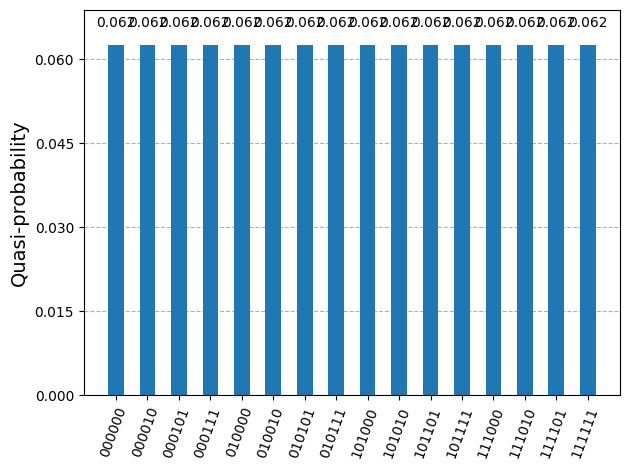

In [140]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(6)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.h(4)
qc.h(5)
qc.cz(0,1)
qc.cz(1,2)
qc.cz(1,4)
qc.cz(3,4)
qc.cz(4,5)
qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.h(4)
qc.h(5)

qc.draw("mpl")

#get the state vector of the above circuit
from qiskit.quantum_info import Statevector
state = Statevector.from_instruction(qc)
#format the state vector as a list of amplitudes
with np.printoptions(precision=4, suppress=True):
    print(state)

#histogram of the amplitudes
from qiskit.visualization import plot_histogram
#make sure to only plot the states with non zero amplitudes
non_zero_states = {state: prob for state, prob in state.probabilities_dict().items() if prob > 1e-16}
import matplotlib.pyplot as plt
plot_histogram(non_zero_states)

